In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

In [2]:
import pandas as pd

tokens_salsa = '#%()+-0123456789<=>BCFHILNOPRSX[]cnos'
fname = 'data/model_ready/dyes/full/anchor_smiles.csv'
df = pd.read_csv(fname)
# display(df)
tokens_dyes = list(set(list(''.join(df.smiles.values))))
print(len(tokens_dyes), len(tokens_salsa))

32 37


### 1) Compute morgan fps.

In [3]:
from benchmark_utils import get_latents
from utilities.fp_utils import get_fps_in_parallel
import numpy as np

seedy = 666

def undo_BrCl_singles(smi):
    smi = smi.replace('R','Br')
    return smi.replace('L','Cl')
def do_BrCl_singles(smi):
    smi = smi.replace('Br','R')
    return smi.replace('Cl','L')   

# # # # # # # # # # # #
load_bs = 50
# # # # # # # # # # # #

tags = ['2022041804_04',  # salsa
        '2022041807_a03', # contrastive encoder 
        '2022041809_a04', # vanilla ae
        'morgan']         # morgan fingerprint

for tag in tags:
    
    if tag!='morgan':
        continue
    
    df = pd.read_csv(fname)
    smis = [undo_BrCl_singles(sm) for sm in df.smiles]
    fps = get_fps_in_parallel(smis,fp_type='morgan',counts=False,bits=1024,radius=4)
    X = np.stack(fps)

In [4]:
fname = 'data/dye_data/hex_cansmi_salsified.csv'
df_hex = pd.read_csv(fname)
# display(df_hex)
# print(X.shape)

### 2) UMAP the latents and plot scatter.

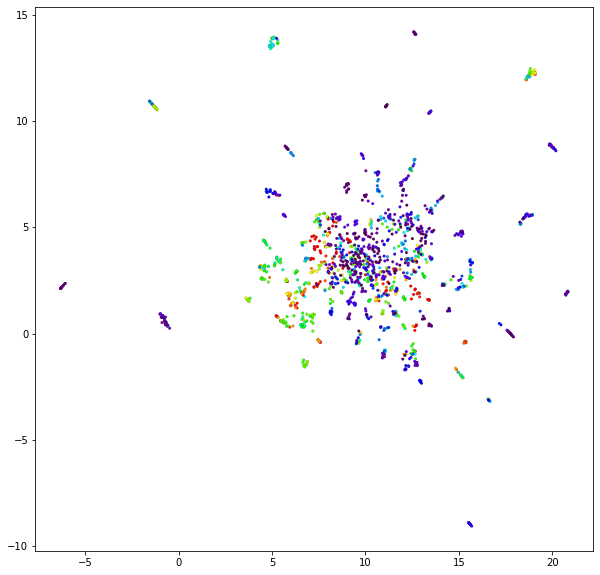

In [14]:
import umap.umap_ as umap

min_d = 0.3
n_ne = 10 #32

umapper = umap.UMAP(n_neighbors=n_ne, min_dist=min_d, n_components=2, metric='euclidean')
embedding = umapper.fit_transform(X)

df_umap = pd.DataFrame(columns=['smi','λ','x','y'])
df_umap['x'] = embedding[:,0]
df_umap['y'] = embedding[:,1]
df_umap['smi'] = df_hex.cansmi
df_umap['λ'] = df_hex.hex
# df_umap

import matplotlib.pyplot as plt

x = df_umap['x']
y = df_umap['y']
cs = df_umap['λ']

fig = plt.figure(figsize=(10,10))
plt.scatter(x, y, s=8, c=cs,
            lw=0.1,
            edgecolors='k')
plt.show()

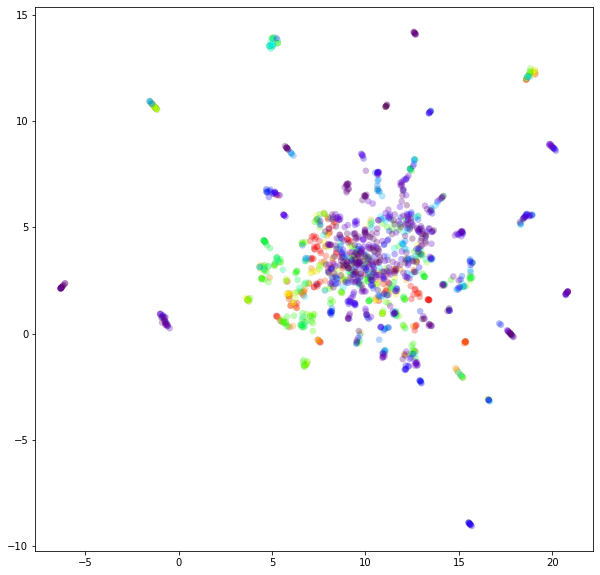

In [16]:
fig = plt.figure(figsize=(10,10))
plt.scatter(x, y, s=40, c=cs,
            lw=0.1, alpha=0.3,
            edgecolors='k')
plt.show()